In [1]:
import os 
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import scgen
from scgen.file_utils import ensure_dir, ensure_dir_for_file, get_dense_X, to_dense
import seaborn as sns
from scipy import stats
sc.set_figure_params(dpi_save=300)

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
2026-02-16 00:13:54.230786: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 00:13:54.326262: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH:

Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
path_to_save = "../results/Figures/Supplemental Figure 8/"
ensure_dir(path_to_save)
sc.settings.figdir = path_to_save

In [ ]:
salmonella = scgen.load_file("../data/train_salmonella.h5ad")
salmonella

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 4259 × 7000
    obs: 'batch', 'barcode', 'condition', 'cell_label', 'n_counts', 'n_genes', 'mt_frac'
    var: 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_label_colors', 'condition_colors', 'neighbors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'

In [4]:
salmonella.obs.groupby(['cell_label', 'condition']).size()

/tmp/ipykernel_66909/129644644.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salmonella.obs.groupby(['cell_label', 'condition']).size()


cell_label             condition 
Endocrine              Control        98
                       Salmonella     62
Enterocyte             Control       367
                       Salmonella    594
Enterocyte.Progenitor  Control       466
                       Salmonella    198
Goblet                 Control       190
                       Salmonella    103
Stem                   Control       570
                       Salmonella    174
TA                     Control       350
                       Salmonella     95
TA.Early               Control       676
                       Salmonella    250
Tuft                   Control        48
                       Salmonella     18
dtype: int64

In [ ]:
kang = scgen.load_file("../data/train_pbmc.h5ad")
kang

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 16893 × 6998
    obs: 'condition', 'n_counts', 'n_genes', 'mt_frac', 'cell_type'
    var: 'gene_symbol', 'n_cells'
    uns: 'cell_type_colors', 'condition_colors', 'neighbors'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'distances', 'connectivities'

In [6]:
kang.obs.groupby(['cell_type', 'condition']).size()

/tmp/ipykernel_66909/487677055.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kang.obs.groupby(['cell_type', 'condition']).size()


cell_type    condition 
CD4T         control       2437
             stimulated    3127
CD14+Mono    control       1946
             stimulated     615
B            control        818
             stimulated     993
CD8T         control        574
             stimulated     541
NK           control        517
             stimulated     646
FCGR3A+Mono  control       1100
             stimulated    2501
Dendritic    control        615
             stimulated     463
dtype: int64

In [7]:
def interpolation_plot(adata, cell_type, data_name, figure, conditions, cell_type_key):
    network = scgen.VAEArith(x_dimension=adata.shape[1], z_dimension=100, model_path=f"../models/scGen/{data_name}/{cell_type}/scgen")
    network.restore_model()
    
    cell_type_adata = adata[adata.obs[cell_type_key] == cell_type]
    cell_type_adata_ctrl = cell_type_adata[cell_type_adata.obs["condition"] == conditions["ctrl"]]
    net_train_data = adata[~((adata.obs[cell_type_key] == cell_type) & (adata.obs["condition"] == conditions["stim"]))]
    
    if data_name == "pbmc":
        cell_type_adata_ctrl = to_dense(cell_type_adata_ctrl)
        sc.tl.rank_genes_groups(cell_type_adata, groupby="condition", n_genes=10, method="wilcoxon")
        diff_genes = cell_type_adata.uns["rank_genes_groups"]["names"][conditions["stim"]].tolist()
    elif data_name == "salmonella":
        sc.tl.rank_genes_groups(cell_type_adata, groupby="condition", n_genes=10, method="wilcoxon")
        diff_genes = cell_type_adata.uns["rank_genes_groups"]["names"][conditions["stim"]].tolist()[:5] + cell_type_adata.uns["rank_genes_groups"]["names"][conditions["ctrl"]].tolist()[:5] 
    pred, delta = network.predict(net_train_data, conditions, cell_type_key, "condition", celltype_to_predict=cell_type)
    
    pred_adata = anndata.AnnData(pred, obs={"condition": ["pred"] * len(pred)},
                                 var={"var_names": cell_type_adata.var_names})
    all_adata = cell_type_adata.concatenate(pred_adata)
    ctrl = all_adata[all_adata.obs["condition"] == conditions["ctrl"]]
    stim = all_adata[all_adata.obs['condition'] == conditions['stim']]
    pred_stim = all_adata[all_adata.obs["condition"] == "pred"]
    inter_cdm = sc.AnnData(network.linear_interpolation(ctrl, pred_stim, 2000))
    inter_cdm.var_names = adata.var_names
    if data_name == "pbmc":
        pred_stim = to_dense(pred_stim)
    all_adata = sc.AnnData(np.concatenate([get_dense_X(cell_type_adata_ctrl), get_dense_X(pred_stim), get_dense_X(inter_cdm)]))
    all_adata.obs["condition"] = ["ctrl"] * len(cell_type_adata_ctrl.X) + ["pred_stim"] * len(pred_stim) + \
                                 ["intermediate"] * len(inter_cdm.X)
    all_adata.var_names = cell_type_adata[3].var_names
    
    print(ctrl.shape, pred_stim.shape, stim.shape)
    
    sc.tl.pca(all_adata)
    to_show  = "condition"
    sc.pl.pca(all_adata, color=to_show, save=f"_{data_name}_{cell_type}.pdf", show=True, frameon=False)
    os.rename(src=os.path.join(path_to_save, f"pca_{data_name}_{cell_type}.pdf"), 
              dst=os.path.join(path_to_save, f"SupplFig8{figure}_{data_name}_{cell_type}.pdf"))
    
    heatmap_data = inter_cdm[:, diff_genes].X
    col_names = diff_genes
    df = pd.DataFrame(heatmap_data)
    df.columns = col_names
    df.to_csv(ensure_dir_for_file(os.path.join("./", cell_type+".txt")))

2026-02-16 00:13:56.681075: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 00:13:56.699217: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-02-16 00:13:56.699321: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-02-16 00:13:56.699413: W tensorflow/stream_executor/platform/default/

INFO:tensorflow:Restoring parameters from ../models/scGen/pbmc/CD4T/scgen


/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/tmp/ipykernel_66909/499730642.py:20: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  all_adata = cell_type_adata.concatenate(pred_adata)


(2437, 6998) (2437, 6998) (3127, 6998)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

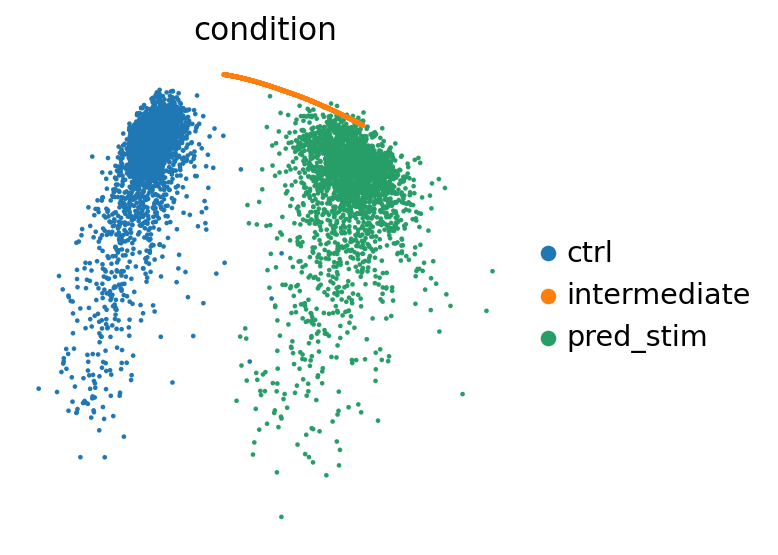

In [8]:
conditions = {"ctrl": "control", "stim": "stimulated"}
interpolation_plot(kang, "CD4T", "pbmc", "b", conditions, "cell_type")

2026-02-16 00:14:03.876176: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1934] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


INFO:tensorflow:Restoring parameters from ../models/scGen/salmonella/TA/scgen


/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/tmp/ipykernel_66909/499730642.py:20: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  all_adata = cell_type_adata.concatenate(pred_adata)


(350, 7000) (350, 7000) (95, 7000)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

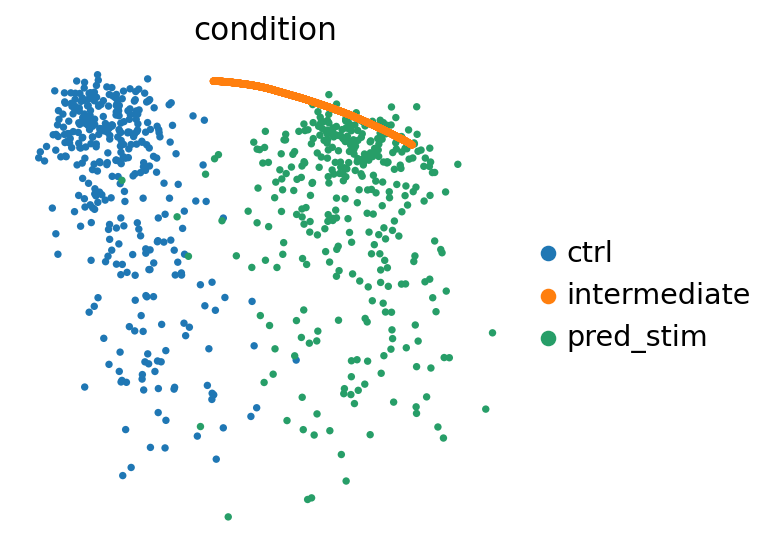

In [9]:
conditions = {"ctrl": "Control", "stim": "Salmonella"}
interpolation_plot(salmonella, "TA", "salmonella", "a", conditions, "cell_label")

In [12]:
%load_ext rpy2.ipython

In [13]:
%%R
if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager", repos = "https://cloud.r-project.org")
BiocManager::install("ComplexHeatmap")

* installing *source* package ‘shape’ ...
** this is package ‘shape’ version ‘1.4.6.1’
** package ‘shape’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** demo
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (shape)
* installing *source* package ‘rjson’ ...
** this is package ‘rjson’ version ‘0.2.23’
** package ‘rjson’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘x86_64-conda-linux-gnu-cc (conda-forge gcc 14.3.0-17) 14.3.0’
using C++ compiler: ‘x86_64-conda-linux-gnu-c++ (conda-forge gcc 14.3.0-17) 14.3.0’


x86_64-conda-linux-gnu-c++ -std=gnu++17 -I"/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/R/include" -DNDEBUG   -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /home/sagemaker-user/.conda/envs/scgen-repro-env/include -I/home/sagemaker-user/.conda/envs/scgen-repro-env/include -Wl,-rpath-link,/home/sagemaker-user/.conda/envs/scgen-repro-env/lib    -fpic  -fvisibility-inlines-hidden  -fmessage-length=0 -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /home/sagemaker-user/.conda/envs/scgen-repro-env/include -fdebug-prefix-map=/home/conda/feedstock_root/build_artifacts/r-base-split_1766426576771/work=/usr/local/src/conda/r-base-4.5.2 -fdebug-prefix-map=/home/sagemaker-user/.conda/envs/scgen-repro-env=/usr/local/src/conda-prefix   -c dump.cpp -o dump.o
x86_64-conda-linux-gnu-cc -I"/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/R/include" -DNDEBUG   -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /home/sagemaker-user/

installing to /home/sagemaker-user/.conda/envs/scgen-repro-env/lib/R/library/00LOCK-rjson/00new/rjson/libs
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (rjson)
* installing *source* package ‘iterators’ ...
** this is package ‘iterators’ version ‘1.0.14’
** package ‘iterators’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed packag

x86_64-conda-linux-gnu-cc -I"/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/R/include" -DNDEBUG   -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /home/sagemaker-user/.conda/envs/scgen-repro-env/include -I/home/sagemaker-user/.conda/envs/scgen-repro-env/include -Wl,-rpath-link,/home/sagemaker-user/.conda/envs/scgen-repro-env/lib    -fpic  -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /home/sagemaker-user/.conda/envs/scgen-repro-env/include -fdebug-prefix-map=/home/conda/feedstock_root/build_artifacts/r-base-split_1766426576771/work=/usr/local/src/conda/r-base-4.5.2 -fdebug-prefix-map=/home/sagemaker-user/.conda/envs/scgen-repro-env=/usr/local/src/conda-prefix  -c assignment.c -o assignment.o
x86_64-conda-linux-gnu-cc -I"/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/R/include" -DNDEBUG   -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /home/sagemaker-user/.conda/envs/scgen-repro-env/include -I/home/sagemaker

installing to /home/sagemaker-user/.conda/envs/scgen-repro-env/lib/R/library/00LOCK-clue/00new/clue/libs
** R
** data
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (clue)
* installing *source* package ‘GlobalOptions’ ...
** this is package ‘GlobalOptions’ version ‘0.1.3’
** package ‘GlobalOptions’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if 

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)
Installing package(s) 'ComplexHeatmap'
also installing the dependencies ‘shape’, ‘rjson’, ‘iterators’, ‘circlize’, ‘GetoptLong’, ‘clue’, ‘GlobalOptions’, ‘foreach’, ‘doParallel’

trying URL 'https://cloud.r-project.org/src/contrib/shape_1.4.6.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/rjson_0.2.23.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/iterators_1.0.14.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/circlize_0.4.17.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/GetoptLong_1.1.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/clue_0.3-66.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/GlobalOptions_0.1.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/foreach_1.5.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/doParallel_1.0.17.tar.gz'
trying URL 'https://bioconductor.org/packages/3.22/bioc/src/contrib/Co

In [14]:
import subprocess
import sys
from pathlib import Path

# Force Rscript from the active Jupyter kernel environment.
rscript = Path(sys.prefix) / "bin" / "Rscript"
subprocess.check_call([str(rscript), "--vanilla", "SupplFig8.R"])


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: grid
ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))



[1] 2000   11
[1] 2000   10
null device 
          1 
[1] 2000   11
[1] 2000   10
null device 
          1 
